In [1]:
import zarr
import s3fs
import numpy as np
from scipy.linalg import solve_banded

S3_BUCKET = "simulations"
STORE_PATH = "flow_export/A1"

fs = s3fs.S3FileSystem(profile='default', client_kwargs={
        'endpoint_url': 'http://localhost:9000'
    })

s3_map = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/data.zarr", s3=fs)
z = zarr.open(
    store=s3_map,
    mode="r",
)

In [2]:
z.shape

(1694, 5, 128, 129, 128)

In [3]:
data = z[51::50]

In [4]:
data.shape

(33, 5, 128, 129, 128)

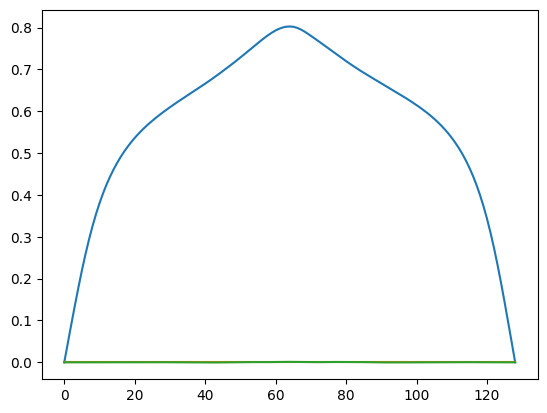

In [5]:
import matplotlib.pyplot as plt
    
plt.plot(data[:, 0].mean((0, 1, 3)))
plt.plot(data[:, 1].mean((0, 1, 3)))
plt.plot(data[:, 2].mean((0, 1, 3)))
plt.show()

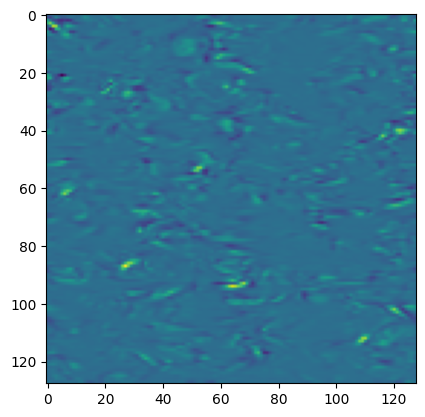

In [6]:
plt.imshow(data[6, 4, :, 50, :])
plt.show()

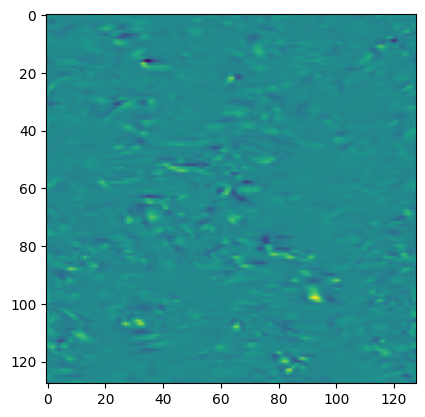

In [7]:
plt.imshow(data[7, 4, :, 50, :])
plt.show()

In [16]:
def get_grad_func(channel):
    yp = channel['y']
    Lx = channel['x'][-1]
    Nx = channel['x'].shape[0]
    Ly = channel['y'][-1]
    Ny = channel['y'].shape[0]
    Lz = channel['z'][-1]
    Nz = channel['z'].shape[0]
    delta_yp = np.gradient(yp, Ly / (Ny - 1))
    y_stretching = 1.0 / delta_yp 
    
    def broadcast_to(source, target, index):
        d = source.shape
        target_shape = list(target.shape)
        for i in range(len(target_shape)):
            if i != index:
                target_shape[i] = 1
        return source.reshape(tuple(target_shape))
    
    
    def derive_fft(u, direction, h):
        n = u.shape[direction]
        k = 2.0 * np.pi * np.fft.fftfreq(n, d=h)
        k_broad = broadcast_to(k, u, direction)
        u_hat = np.fft.fftn(u, axes=(direction,))
        u_hat_prime = 1.0j * k_broad * u_hat
        return np.fft.ifftn(u_hat_prime, axes=(direction,)).real
    
    
    def derive_compact(u, direction, h):
        rhs = np.zeros_like(u)
        rhs = np.roll(u, -1, axis=direction) - np.roll(u, 1, axis=direction)
        rhs *= 3.0 / h
        length = u.shape[direction]
        ab = np.zeros((3, length))
        ab[0, 2:] = 1
        ab[1, :] = 4
        ab[2, :-2] = 1
        # BC
        ab[0, 1] = 0
        ab[2, -2] = 0
        rhs_reordered = np.moveaxis(rhs, direction, 0)
        reordered_shape = rhs_reordered.shape
        rhs_reshaped = rhs_reordered.reshape(length, -1)
        u_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
        u_prime = np.moveaxis(u_prime_reshaped.reshape(reordered_shape), 0, direction)
        return u_prime
    
    def grad(field):
        T, C, X, Y, Z = field.shape
        grad = np.zeros((T, C, 3, X, Y, Z))
        grad[:, :, 0, :, :, :] = derive_fft(field, 2, Lx / Nx)
        grad[:, :, 1, :, :, :] = derive_compact(field, 3, Ly / (Ny - 1)) * y_stretching[None, None, None, :, None]
        grad[:, :, 2, :, :, :] = derive_fft(field, 4, Lz / Nz)
        return grad

    return grad

In [17]:
store = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/channel.zarr", s3=fs)
channel_z = zarr.open(
    store=store,
    mode="r",
)
channel = {'x': channel_z['x'][:], 'y': channel_z['y'][:], 'z': channel_z['z'][:]}


In [18]:
grad = get_grad_func(channel)

In [19]:
u_grad = grad(data)

In [27]:
Q = -0.5 * np.einsum('tikxyz, tjixyz->txyz', u_grad, u_grad)

ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (33,5,3,128,129,128)->(33,128,129,128,5,newaxis,3) (33,5,3,128,129,128)->(33,128,129,128,3,5,newaxis) 

In [15]:
data.shape

(33, 5, 128, 129, 128)